<a href="https://colab.research.google.com/github/one-2730/ESSA-25-1/blob/Assignment/ESAA_OB_0526_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#7. 시계열

##7.1 시계열 문제

- 불규칙 변동
- 추세 변동
- 순환 변동
- 계절 변동

불규칙적 시계열 데이터에 규칙성을 부여한느 방법: AR, MA, ARMA, ARIMA

##7.2 AR, MA, ARMA, ARIMA

###7.2.1 AR
자기회귀 모델
idea: 이전 관측 값이 이후 관측 값에 영향을 줌
현재 시점=과거*과거 영향+오차

###7.2.2 MA
이동평균 모델 : 트렌드가 변화하는 상황에 적합
idea: 시계열을 따라 윈도우*만큼 슬라이딩
현재 시점=매개변수*과거 오차+오차

###7.2.3 ARMA
AR, MA 관점에서 과거의 데이터 사용

###7.2.4 ARIMA
ARMA는 선형 관계만 고려, ARIMA는 추세까지 고려
1. ARIMA(p, d, q)
- p: 자기 회귀 차수
- d: 차분 차수
- q: 이동 평균 차수

In [22]:
from pandas import read_csv
from datetime import datetime
from pandas import DataFrame
from matplotlib import pyplot
from statsmodels.tsa.arima.model import ARIMA

<ipython-input-24-86cfa3606b80>:6: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  series = read_csv('sales.csv', header=0, parse_dates=[0], index_col=0, date_parser=parser)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                           SARIMAX Results                                           
Dep. Variable:     Sales of shampoo over a three year period   No. Observations:                   36
Model:                                        ARIMA(5, 1, 0)   Log Likelihood                -198.485
Date:                                       Wed, 28 May 2025   AIC                            408.969
Time:                                               08:17:12   BIC                            418.301
Sample:                                           01-01-1991   HQIC                           412.191
                                                - 12-01-1993                                         
Covariance Type:                                         opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9014     

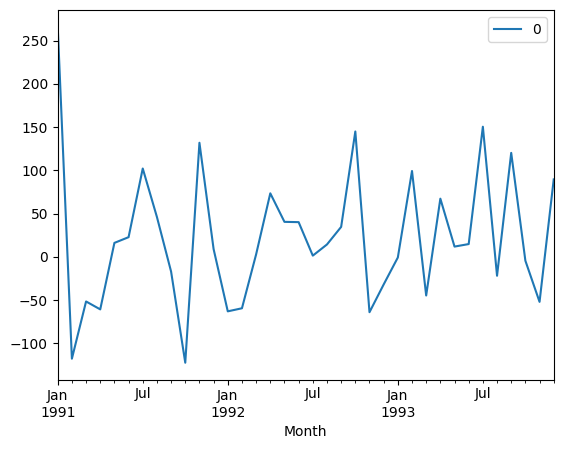

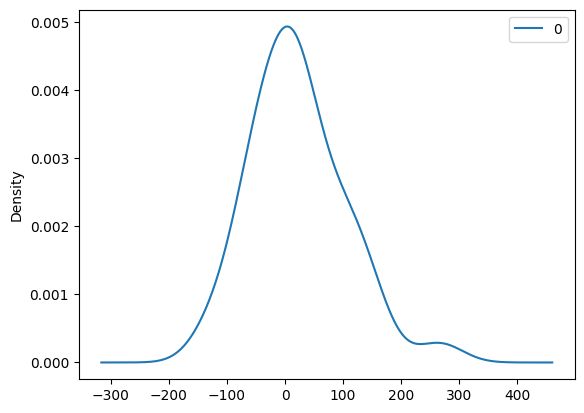

                0
count   36.000000
mean    21.936144
std     80.774430
min   -122.292030
25%    -35.040859
50%     13.147219
75%     68.848286
max    266.000000


In [24]:
#ARIMA() 함수를 호출하여 sales 데이터셋에 대한 예측

def parser(x):
  return datetime.strptime('199'+x, '%Y-%m')

series = read_csv('sales.csv', header=0, parse_dates=[0], index_col=0, date_parser=parser)
series = series.iloc[:, 0]
model = ARIMA(series, order=(5, 1, 0))
model_fit = model.fit()
print(model_fit.summary())
residuals = DataFrame(model_fit.resid)
residuals.plot()
pyplot.show()
residuals.plot(kind='kde')
pyplot.show()
print(residuals.describe())

predicted=343.272180, expected=342.300000
predicted=293.329674, expected=339.700000
predicted=368.668956, expected=440.400000
predicted=335.044741, expected=315.900000
predicted=363.220222, expected=439.300000
predicted=357.645324, expected=401.300000
predicted=443.047835, expected=437.400000
predicted=378.365674, expected=575.500000
predicted=459.415021, expected=407.600000
predicted=526.890876, expected=682.000000
predicted=457.231274, expected=475.300000
predicted=672.914944, expected=581.300000
predicted=531.541449, expected=646.900000
Test MSE: 7924.748


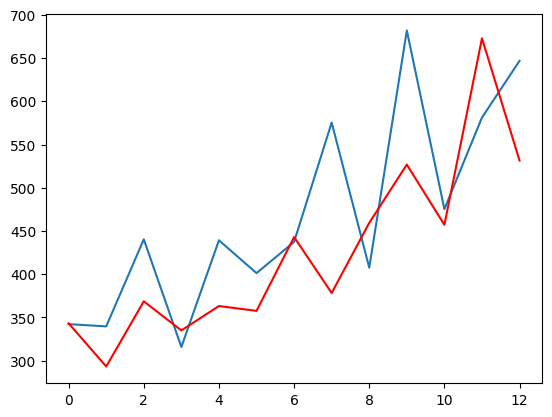

In [26]:
#statsmodels 라이브러리를 이용한 sales 데이터셋 예측

import numpy as np
from sklearn.metrics import mean_squared_error

X = series.values
X = np.nan_to_num(X)
size = int(len(X)*0.66)
train, test = X[0:size], X[size:len(X)]
history = [x for x in train]
predictions = list()
for t in range(len(test)):
  model = ARIMA(history, order = (5, 1, 0))
  model_fit = model.fit()
  output = model_fit.forecast()
  yhat = output[0]
  predictions.append(yhat)
  obs = test[t]
  history.append(obs)
  print('predicted=%f, expected=%f' % (yhat, obs))
error = mean_squared_error(test, predictions)
print('Test MSE: %.3f' % error)
pyplot.plot(test)
pyplot.plot(predictions, color='red')
pyplot.show()

##7.3 RNN

RNN 차별점: memory를 가짐



input 마다 memory 수정, 최종 memory -> 모든 input 요약


RNN 유형
1. 일대일: RNN 아님(순환이 없음)
2. 일대다: 입력이 하나, 출력이 다수 ex.이미지캡션
3. 다대일: 입력이 다수, 출력이 하나 ex.감성분석
4. 다대다: 입력, 출력이 다수 ex.번역기
5. 동기화 다대다

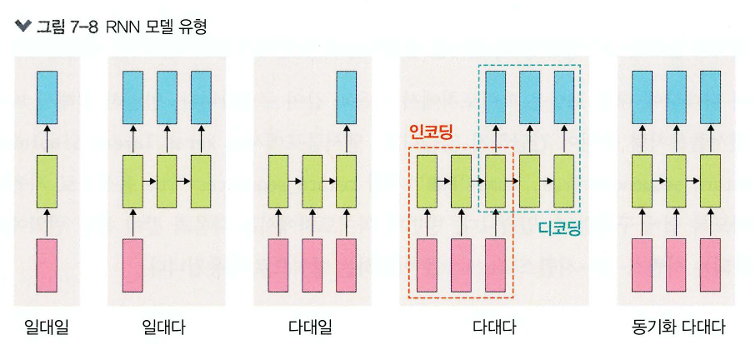

###RNN 실습

In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

In [28]:
input_str = 'apple'
label_str = 'pple!'
char_vocab = sorted(list(set(input_str+label_str)))
vocab_size = len(char_vocab)
print('문자 집합의 크기: {}'.format(vocab_size))

문자 집합의 크기: 5


In [29]:
input_size = vocab_size
hidden_size = 5
output_size = 5
learning_rate = 0.1

In [30]:
char_to_index = dict((c, i) for i, c in enumerate(char_vocab))
print(char_to_index)

{'!': 0, 'a': 1, 'e': 2, 'l': 3, 'p': 4}


In [31]:
index_to_char={}
for key, value in char_to_index.items():
  index_to_char[value] = key
print(index_to_char)

{0: '!', 1: 'a', 2: 'e', 3: 'l', 4: 'p'}


In [32]:
x_data = [char_to_index[c] for c in input_str]
y_data = [char_to_index[c] for c in label_str]
print(x_data)
print(y_data)

[1, 4, 4, 3, 2]
[4, 4, 3, 2, 0]


In [33]:
x_data = [x_data]
y_data = [y_data]
print(x_data)
print(y_data)

[[1, 4, 4, 3, 2]]
[[4, 4, 3, 2, 0]]


In [34]:
x_one_hot = [np.eye(vocab_size)[x] for x in x_data]
print(x_one_hot)

[array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 1., 0.],
       [0., 0., 1., 0., 0.]])]


In [35]:
X = torch.FloatTensor(x_one_hot)
Y = torch.LongTensor(y_data)

<ipython-input-35-c1bfbd518a63>:1: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  X = torch.FloatTensor(x_one_hot)


In [36]:
print('훈련 데이터의 크기: {}'.format(X.shape))
print('레이블의 크기: {}'.format(Y.shape))

훈련 데이터의 크기: torch.Size([1, 5, 5])
레이블의 크기: torch.Size([1, 5])


모델 구현하기

In [39]:
class Net(torch.nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(Net, self).__init__()
    self.rnn = torch.nn.RNN(input_size, hidden_size, batch_first=True)
    self.fc = torch.nn.Linear(hidden_size, output_size, bias=True)

  def forward(self, x):
    x, _status = self.rnn(x)
    x = self.fc(x)
    return x

In [40]:
net = Net(input_size, hidden_size, output_size)

In [41]:
outputs = net(X)
print(outputs.shape)

torch.Size([1, 5, 5])


In [43]:
print(outputs.view(-1, input_size).shape)

torch.Size([5, 5])


In [46]:
print(Y.shape)
print(Y.view(-1).shape)

torch.Size([1, 5])
torch.Size([5])


In [48]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), learning_rate)

In [50]:
for i in range(100):
  optimizer.zero_grad()
  outputs = net(X)
  loss = criterion(outputs.view(-1, input_size), Y.view(-1))
  loss.backward()
  optimizer.step()

  result = outputs.data.numpy().argmax(axis=2)
  result_str = ''.join([index_to_char[c] for c in np.squeeze(result)])
  print(i, 'loss: ', loss.item(), 'prediction: ', result, 'true Y: ', y_data, 'prediction str: ', result_str)

0 loss:  0.001076482585631311 prediction:  [[4 4 3 2 0]] true Y:  [[4, 4, 3, 2, 0]] prediction str:  pple!
1 loss:  0.0010674098739400506 prediction:  [[4 4 3 2 0]] true Y:  [[4, 4, 3, 2, 0]] prediction str:  pple!
2 loss:  0.0010585038689896464 prediction:  [[4 4 3 2 0]] true Y:  [[4, 4, 3, 2, 0]] prediction str:  pple!
3 loss:  0.0010497404728084803 prediction:  [[4 4 3 2 0]] true Y:  [[4, 4, 3, 2, 0]] prediction str:  pple!
4 loss:  0.0010410245740786195 prediction:  [[4 4 3 2 0]] true Y:  [[4, 4, 3, 2, 0]] prediction str:  pple!
5 loss:  0.001032523112371564 prediction:  [[4 4 3 2 0]] true Y:  [[4, 4, 3, 2, 0]] prediction str:  pple!
6 loss:  0.001024069031700492 prediction:  [[4 4 3 2 0]] true Y:  [[4, 4, 3, 2, 0]] prediction str:  pple!
7 loss:  0.0010156863136216998 prediction:  [[4 4 3 2 0]] true Y:  [[4, 4, 3, 2, 0]] prediction str:  pple!
8 loss:  0.0010074941674247384 prediction:  [[4 4 3 2 0]] true Y:  [[4, 4, 3, 2, 0]] prediction str:  pple!
9 loss:  0.0009993495186790824 

더 많은 데이터로 학습한 문자 단위 RNN(Char RNN)

In [51]:
import torch
import torch.nn as nn
import torch.optim as optim

In [52]:
sentence = ("if you want to build a ship, don't drum up people together to"
            "collect wood and don't assign them tasks and work, but rather"
            "teach them to long for the endless immensity of the sea.")

In [53]:
char_set = list(set(sentence))
char_dic = {c: i for i, c in enumerate(char_set)}

print(char_dic)

{'f': 0, 'h': 1, 'k': 2, 's': 3, 'n': 4, ',': 5, 'd': 6, 't': 7, ' ': 8, 'i': 9, "'": 10, 'p': 11, '.': 12, 'g': 13, 'u': 14, 'y': 15, 'e': 16, 'b': 17, 'c': 18, 'm': 19, 'l': 20, 'o': 21, 'r': 22, 'a': 23, 'w': 24}


In [54]:
dic_size = len(char_dic)
print('문자 집합의 크기: {}'.format(dic_size))

문자 집합의 크기: 25


In [55]:
hidden_size = dic_size
sequence_length = 10
learning_rate = 0.1

In [56]:
x_data = []
y_data = []

for i in range(0, len(sentence) - sequence_length):
  x_str = sentence[i:i+sequence_length]
  y_str = sentence[i+1:i+sequence_length+1]
  print(i, x_str, '->', y_str)

  x_data.append([char_dic[c] for c in x_str])
  y_data.append([char_dic[c] for c in y_str])

0 if you wan -> f you want
1 f you want ->  you want 
2  you want  -> you want t
3 you want t -> ou want to
4 ou want to -> u want to 
5 u want to  ->  want to b
6  want to b -> want to bu
7 want to bu -> ant to bui
8 ant to bui -> nt to buil
9 nt to buil -> t to build
10 t to build ->  to build 
11  to build  -> to build a
12 to build a -> o build a 
13 o build a  ->  build a s
14  build a s -> build a sh
15 build a sh -> uild a shi
16 uild a shi -> ild a ship
17 ild a ship -> ld a ship,
18 ld a ship, -> d a ship, 
19 d a ship,  ->  a ship, d
20  a ship, d -> a ship, do
21 a ship, do ->  ship, don
22  ship, don -> ship, don'
23 ship, don' -> hip, don't
24 hip, don't -> ip, don't 
25 ip, don't  -> p, don't d
26 p, don't d -> , don't dr
27 , don't dr ->  don't dru
28  don't dru -> don't drum
29 don't drum -> on't drum 
30 on't drum  -> n't drum u
31 n't drum u -> 't drum up
32 't drum up -> t drum up 
33 t drum up  ->  drum up p
34  drum up p -> drum up pe
35 drum up pe -> rum up peo
36

In [57]:
print(x_data[0])
print(y_data[0])

[9, 0, 8, 15, 21, 14, 8, 24, 23, 4]
[0, 8, 15, 21, 14, 8, 24, 23, 4, 7]


In [58]:
x_one_hot = [np.eye(dic_size)[x] for x in x_data]
X = torch.FloatTensor(x_one_hot)
Y = torch.LongTensor(y_data)

print('훈련 데이터의 크기: {}'.format(X.shape))
print('레이블의 크기: {}'.format(Y.shape))

훈련 데이터의 크기: torch.Size([168, 10, 25])
레이블의 크기: torch.Size([168, 10])


In [59]:
print(X[0])

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
         0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,

In [60]:
print(Y[0])

tensor([ 0,  8, 15, 21, 14,  8, 24, 23,  4,  7])


모델 구현하기

In [61]:
class Net(torch.nn.Module):
  def __init__(self, input_dim, hidden_dim, layers):
    super(Net, self).__init__()
    self.rnn = torch.nn.RNN(input_dim, hidden_dim, num_layers=layers, batch_first=True)
    self.fc = torch.nn.Linear(hidden_dim, hidden_dim, bias=True)

  def forward(self, x):
    x, _status = self.rnn(x)
    x = self.fc(x)
    return x

In [62]:
net = Net(dic_size, hidden_size, 2)

In [63]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), learning_rate)

In [64]:
outputs = net(X)
print(outputs.shape)

torch.Size([168, 10, 25])


In [65]:
print(outputs.view(-1, dic_size).shape)

torch.Size([1680, 25])


In [66]:
print(Y.shape)
print(Y.view(-1).shape)

torch.Size([168, 10])
torch.Size([1680])


In [67]:
for i in range(100):
  optimizer.zero_grad()
  outputs = net(X)
  loss = criterion(outputs.view(-1, dic_size), Y.view(-1))
  loss.backward()
  optimizer.step()

  results = outputs.argmax(dim=2)
  predict_str = ""
  for j, result in enumerate(results):
    if j == 0:
      predict_str += ''.join([char_set[t] for t in result])
    else:
      predict_str += char_set[result[-1]]

  print(predict_str)

ddddsgddggdgdddggddgggddgdgsdgdgsddgggddggdggdgsgddddgsddddddddsdgddddddggggpgddgsddggggdgdddgdddggdggggggddgggdggddggsdgddggdddddddddddddgdgdddddddddgdgdgggdddggdgdggddddddddgg
                                                                                                                                                                                 
 tttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttt
  d.  s.p                                                                                                                                                                        
                                                                                                                                                                                 
 oio  soodn  sn    n  n d d d n  nd soin  s         dsn  ho sdod o  sndn  odn  sn  s n  n d    s d   sn os    